# Null-model QC: how many DE genes appear with no real contrast?

`redo_de_genes.ipynb` tests **treatment vs Control**. This notebook re-runs analyses
**1 (library-level pseudobulk)** and **2 (leiden micro-cluster pseudobulk)** with the treatment
contrast replaced by a *mock* one: inside each treatment, cells are randomly labelled `A` or `B`,
and `A` is tested against `B`.

The mock labels are drawn independently of expression, so **every gene called significant is a
false positive by construction**. The counts below are therefore a direct read on how
anti-conservative each design is:

| statistic | what a calibrated test should give |
|---|---|
| fraction of genes with raw `p < 0.05` | ~5% |
| genes with `padj < 0.05` | ~0 |

Each analysis is repeated over several independent random splits, and the whole thing is run
separately within `Control`, `Drought`, `Heat` and `HD`, so there are 4 null replicates per split.

**Two ways to randomise, and they answer different questions.**

* *Cell-level split* (what the request asks for, and the default here) — every cell is
  independently assigned to `A` or `B`. This destroys all structure above the single cell, so the
  two groups are matched on library, cell type and micro-cluster. It measures the **technical
  floor**: the false positives you get from counting noise alone.
* *Unit-level split* (section 2b, an addition) — whole micro-clusters are assigned to `A` or `B`.
  The cluster stays intact, so the between-cluster variability that analysis 2 treats as
  replicate noise is preserved. This is the null that actually probes **pseudo-replication**,
  which is the stated caveat of analysis 2.

> **Caveat — these are lower bounds.** Every mock contrast here is *within* a treatment, so the
> `A` and `B` groups are drawn from the same libraries. None of them contains the between-library
> batch variation that separates the real Control libraries from the real Drought/Heat/HD ones,
> and in the real analysis library is perfectly confounded with treatment (it cannot be added to
> the design as a covariate). The false positive counts below therefore **bound the real rate from
> below**: a design that fails here is definitely anti-conservative, but one that passes has only
> been cleared of counting noise and pseudo-replication, not of batch effects. This bites hardest
> on analysis 1, where the two mock groups are literally two halves of the same library. A null
> that did include the batch term would permute treatment labels across whole libraries; with 3-4
> libraries per treatment there are too few distinct permutations for that to be informative.

Analysis 3 (the multifactor design) is not repeated here, as requested.

In [19]:
from pathlib import Path
import time

import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import scanpy as sc
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from scipy import sparse

## Configuration

`N_SPLITS` controls how many independent random labellings are run. Analysis 1 fits 8 or fewer
pseudosamples and is seconds per fit; analysis 2 fits several hundred pseudosamples and is
minutes per fit, so it gets its own (smaller) count. Total fits are
`N_SPLITS * 4` for analysis 1 and `N_SPLITS_MICRO * 4` for each of 2 and 2b.

In [20]:
RAW_H5AD = Path(
    r"C:\Users\mikep\git\Soybean_Single_Cell_drought_heat\Data\anndata_export\adata_rna.h5ad"
)
REAL_RESULTS_DIR = Path("de_results")  # tables written by redo_de_genes.ipynb
RESULTS_DIR = REAL_RESULTS_DIR / "mock_qc"  # this notebook writes here

TREATMENTS = ["Control", "Drought", "Heat", "HD"]
MOCK_KEY = "mock"
MOCK_LEVELS = ["A", "B"]
MOCK_CONTRAST = [MOCK_KEY, "B", "A"]

LEIDEN_KEY = "leiden_within_library"  # micro-clusters, computed one library at a time
LEIDEN_RES = 9  # same value redo_de_genes.ipynb was run with

MIN_GENE_TOTAL = 10  # gene filter: total counts across pseudosamples
MIN_GENE_FRAC = 0.10  # gene filter: fraction of pseudosamples with a non-zero count
MIN_CELLS_PER_SAMPLE = (
    3  # drop tiny pseudosamples (halving a micro-cluster can leave 1 cell)
)
ALPHA, LFC_CUT = 0.05, 1.0  # thresholds used for the significance summaries
# "ratio" is the PyDESeq2 default used by redo_de_genes.ipynb; halved micro-clusters are sparse
# enough that no gene is non-zero in every pseudosample, which sends "ratio" into its iterative
# fallback -- that fallback is slow and often does not converge, so use "poscounts" there.
MICRO_SIZE_FACTORS = "poscounts"
N_CPUS = 8

SEED = 0
N_SPLITS = 5  # analyses 1 / 1b: cheap
N_SPLITS_MICRO = 2  # analyses 2 / 2b: minutes per fit
RUN_UNIT_LEVEL_MOCK = True  # section 2b

SAVE_SUMMARIES = True
SAVE_FULL_TABLES = False  # full PyDESeq2 tables for every mock fit (tens of MB)

# light-mode chart colors: categorical slots 1-4 in the documented order, plus muted ink.
# Four analyses now reach the grouped bar chart, so a three-colour list would have cycled and
# repainted the fourth series with slot 1's blue.
SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
MUTED_INK = "#898781"
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
        "axes.edgecolor": "#c3c2b7",
    }
)

## Load raw counts

Only raw integer counts and the stored PCA are needed: the micro-clustering in analysis 2 runs on
`X_pca`, which is read from the h5ad and unaffected by normalisation, so the
normalise / log1p / global-leiden steps at the top of `redo_de_genes.ipynb` are not repeated.

In [21]:
adata = sc.read_h5ad(RAW_H5AD)


def is_integer(mat):
    data = mat.data if sparse.issparse(mat) else np.asarray(mat).ravel()
    return bool(np.allclose(data, np.rint(data)))


if not is_integer(adata.layers["counts"]):
    raise ValueError("layers['counts'] does not hold raw integer counts")

counts_adata = ad.AnnData(
    X=adata.layers["counts"].copy(), obs=adata.obs.copy(), var=adata.var.copy()
)
counts_adata.obs["treatment"] = pd.Categorical(
    counts_adata.obs["treatment"].astype(str), categories=TREATMENTS
)
del adata.layers["counts"]  # the copy above is independent; free the duplicate

print(counts_adata)
print("\ncells per treatment / library:")
print(counts_adata.obs.groupby(["treatment", "libraries"], observed=True).size())

AnnData object with n_obs × n_vars = 30467 × 36042
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'pctCP', 'pctMT', 'nUMI_raw', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'treatment', 'libraries', 'replicate', 'source_rds', 'integrated_snn_res.0.5', 'celltype_call', 'cluster_annot'
    var: 'highly_variable', 'in_integrated'
    layers: None (.X)

cells per treatment / library:
treatment  libraries         
Control    leaf_control_rep1     3740
           leaf_control_rep1A    3452
           leaf_control_rep2      823
           leaf_control_rep3     1683
Drought    leaf_drought_rep1     1434
           leaf_drought_rep2     2855
           leaf_drought_rep3     1036
Heat       leaf_Heat_rep1         939
           leaf_Heat_rep2        2381
           leaf_Heat_rep3        2193
HD         leaf_HD_rep1          5538

## Mock condition assignment

`assign_mock` splits cells 50/50 into `A` and `B` *within* strata. Two knobs:

* `strata_keys` — the split is balanced inside every stratum, so the mock groups are matched on
  those variables rather than differing by them at random. Analysis 1 splits within
  `treatment x library`; analysis 2 within `treatment x micro-cluster`.
* `unit_key` — if given, whole units (e.g. micro-clusters) are assigned rather than single cells,
  keeping each unit intact. Used by section 2b.

Odd-sized strata hand their leftover cell to a randomly chosen side, so neither mock group is
systematically larger. Randomness comes from `np.random.default_rng(seed)`, so every split is
reproducible from its seed.

In [22]:
def assign_mock(obs, strata_keys, seed, unit_key=None):
    """Randomly label cells `A` or `B`, balanced inside every stratum.

    Labels are independent of expression, so any gene called differential between them is a
    false positive. With `unit_key` set, whole units (e.g. micro-clusters) are assigned to one
    side instead of being split, which preserves the between-unit variability.
    """
    rng = np.random.default_rng(seed)
    keys = list(strata_keys) + ([unit_key] if unit_key is not None else [])
    unlabelled = obs[keys].isna().any()
    if unlabelled.any():
        raise ValueError(
            f"cells with no label in {list(unlabelled[unlabelled].index)} -- "
            "every cell needs one (did the micro-cluster cell run?)"
        )
    strata = obs[list(strata_keys)].astype(str).agg(" | ".join, axis=1)
    units = (
        obs[unit_key].astype(str)
        if unit_key is not None
        else pd.Series(obs.index.astype(str), index=obs.index)
    )
    frame = pd.DataFrame(
        {"stratum": strata.to_numpy(), "unit": units.to_numpy()}, index=obs.index
    )

    if unit_key is None:
        unit_stratum = frame.set_index("unit")["stratum"]  # one unit per cell
    else:
        by_unit = frame.groupby("unit", sort=True)["stratum"]
        if (by_unit.nunique() > 1).any():
            raise ValueError(f"{unit_key!r} is not nested within {list(strata_keys)}")
        unit_stratum = by_unit.first()

    assignment = pd.Series(index=unit_stratum.index, dtype=object)
    for _, group in unit_stratum.groupby(unit_stratum, sort=True):
        perm = rng.permutation(group.index.to_numpy())
        n = len(perm)
        half = n // 2 + int(
            n % 2 and rng.random() < 0.5
        )  # leftover goes to a random side
        assignment[perm[:half]] = MOCK_LEVELS[0]
        assignment[perm[half:]] = MOCK_LEVELS[1]

    labels = assignment.reindex(frame["unit"]).to_numpy()
    return pd.Categorical(labels, categories=MOCK_LEVELS)

## Pseudobulk / DESeq2 helpers

`pseudobulk`, `filter_genes` and `run_deseq` are the same routines as `redo_de_genes.ipynb`, with
the design and contrast made arguments and an extra `n_cells` cutoff. `hit_counts` replaces
`de_summary`: under a null the interesting number is not the direction of change but how far the
p-value distribution departs from uniform.

In [23]:
def pseudobulk(adata, group_keys, meta_keys=()):
    """Sum raw counts within each group of cells.

    Returns (counts, metadata): a pseudosamples x genes integer count matrix, and a matching
    metadata frame holding the grouping columns, the majority value of each `meta_keys` column,
    and the number of cells per pseudosample.
    """
    group_keys = list(group_keys)
    labels = adata.obs[group_keys].astype(str).agg(" | ".join, axis=1).to_numpy()
    cats = pd.Categorical(labels)
    n_cells = np.bincount(cats.codes, minlength=len(cats.categories))

    indicator = sparse.csr_matrix(
        (np.ones(adata.n_obs), (cats.codes, np.arange(adata.n_obs))),
        shape=(len(cats.categories), adata.n_obs),
    )
    summed = indicator @ adata.X
    summed = (
        np.asarray(summed.todense()) if sparse.issparse(summed) else np.asarray(summed)
    )
    counts = pd.DataFrame(
        np.rint(summed).astype(np.int64),
        index=list(cats.categories),
        columns=adata.var_names,
    )

    meta_cols = group_keys + [k for k in meta_keys if k not in group_keys]
    frame = adata.obs[meta_cols].astype(str).copy()
    frame["_group"] = labels
    meta = frame.groupby("_group", observed=True)[meta_cols].agg(
        lambda s: s.value_counts().index[0]
    )
    meta["n_cells"] = pd.Series(n_cells, index=list(cats.categories))
    if "treatment" in meta:
        meta["treatment"] = pd.Categorical(meta["treatment"], categories=TREATMENTS)
    if MOCK_KEY in meta:
        meta[MOCK_KEY] = pd.Categorical(meta[MOCK_KEY], categories=MOCK_LEVELS)
    return counts, meta.loc[counts.index]


def filter_genes(
    counts, min_total=MIN_GENE_TOTAL, min_frac_samples=MIN_GENE_FRAC, verbose=True
):
    """Drop genes with too little signal to be testable (also keeps PyDESeq2 fast)."""
    min_samples = max(2, int(np.ceil(min_frac_samples * counts.shape[0])))
    keep = ((counts > 0).sum(axis=0) >= min_samples) & (counts.sum(axis=0) >= min_total)
    if verbose:
        print(f"genes kept: {int(keep.sum())} / {counts.shape[1]}")
    return counts.loc[:, keep.to_numpy()]


def run_deseq(counts, meta, design, contrasts, n_cpus=N_CPUS, **kwargs):
    """Fit one DESeq2 model and run a Wald test for each contrast."""
    dds = DeseqDataSet(
        counts=counts, metadata=meta, design=design, n_cpus=n_cpus, quiet=True, **kwargs
    )
    dds.deseq2()
    results = {}
    for name, contrast in contrasts.items():
        stat = DeseqStats(dds, contrast=contrast, n_cpus=n_cpus, quiet=True)
        stat.summary()
        results[name] = stat.results_df.sort_values("padj")
    return dds, results


def sig_genes(res, alpha=ALPHA, lfc_cut=LFC_CUT):
    return res.index[(res["padj"] < alpha) & (res["log2FoldChange"].abs() >= lfc_cut)]


def hit_counts(res, alpha=ALPHA, lfc_cut=LFC_CUT):
    """Null-model summary of one results table: p-value calibration plus hit counts."""
    pvals = res["pvalue"].dropna()
    return {
        "genes_tested": int(res["padj"].notna().sum()),
        "% p<0.05": (
            round(100 * float((pvals < 0.05).mean()), 2) if len(pvals) else np.nan
        ),
        "% p<0.01": (
            round(100 * float((pvals < 0.01).mean()), 2) if len(pvals) else np.nan
        ),
        f"padj<{alpha}": int((res["padj"] < alpha).sum()),
        f"padj<{alpha} & |LFC|>={lfc_cut}": len(sig_genes(res, alpha, lfc_cut)),
    }

### The driver

One DESeq2 fit per (split, treatment): the cells of a single treatment are pseudobulked by
`mock x <grouping>` and `B` is contrasted against `A` under `~mock`. Every fit's full results
table is kept in `mock_tables[(analysis, seed, treatment)]` for the plots further down.

In [24]:
def run_mock_analysis(
    adata_counts,
    analysis,
    group_keys,
    strata_keys,
    seeds,
    unit_key=None,
    design=None,
    min_frac_samples=MIN_GENE_FRAC,
    min_cells=MIN_CELLS_PER_SAMPLE,
    treatments=TREATMENTS,
    store=None,
    **deseq_kwargs,
):
    """Mock A-vs-B DESeq2 fit for every (seed, treatment); returns a tidy summary frame.

    `design` defaults to `~mock`. Pass e.g. `~mock + replicate` to block on a batch factor --
    the contrast is named explicitly, so extra terms in the formula do not disturb it.
    """
    design = f"~{MOCK_KEY}" if design is None else design
    store = {} if store is None else store
    rows = []
    for seed in seeds:
        adata_counts.obs[MOCK_KEY] = assign_mock(
            adata_counts.obs, strata_keys, seed, unit_key=unit_key
        )
        for treatment in treatments:
            sub = adata_counts[adata_counts.obs["treatment"] == treatment]
            counts, meta = pseudobulk(
                sub,
                group_keys=[MOCK_KEY, *group_keys],
                meta_keys=["treatment", "libraries"],
            )

            keep = meta["n_cells"] >= min_cells
            dropped = int((~keep).sum())
            counts, meta = counts.loc[keep.to_numpy()], meta.loc[keep]
            per_side = meta[MOCK_KEY].value_counts().reindex(MOCK_LEVELS).fillna(0)
            if (per_side < 2).any():
                print(f"  skipped {treatment} seed {seed}: {per_side.to_dict()}")
                continue

            counts_f = filter_genes(
                counts, min_frac_samples=min_frac_samples, verbose=False
            )
            name = f"{treatment}: B vs A"
            start = time.time()
            _, results = run_deseq(
                counts_f,
                meta,
                design=design,
                contrasts={name: MOCK_CONTRAST},
                **deseq_kwargs,
            )
            res = results[name]
            store[(analysis, seed, treatment)] = res

            row = {
                "analysis": analysis,
                "seed": seed,
                "treatment": treatment,
                "n_A": int(per_side["A"]),
                "n_B": int(per_side["B"]),
                "cells_per_sample": round(float(meta["n_cells"].median()), 1),
                "genes_kept": counts_f.shape[1],
                **hit_counts(res),
            }
            rows.append(row)
            print(
                f"  {analysis} | seed {seed} | {treatment:<8} "
                f"{row['n_A']}v{row['n_B']} samples, {row['genes_tested']:>6} tested, "
                f"{row['% p<0.05']:>5}% p<0.05, {row[f'padj<{ALPHA}']:>6} padj<{ALPHA} "
                f"[{time.time() - start:.0f}s]"
            )
            if SAVE_FULL_TABLES:
                RESULTS_DIR.mkdir(parents=True, exist_ok=True)
                res.to_csv(
                    RESULTS_DIR / f"mock__{analysis}__seed{seed}__{treatment}.csv"
                )
    return pd.DataFrame(rows), store


mock_tables = {}  # (analysis, seed, treatment) -> full PyDESeq2 results frame

## 1. Library-level pseudobulk, mock conditions (`~ mock`)

Each library is split in half at random, giving one `A` and one `B` pseudosample per library: 4
vs 4 in Control, 3 vs 3 in each stress. That matches the sample sizes of the real analysis 1
(4 Control vs 3 stressed), and the gene filter is the same (`min_frac_samples=0.5`).

In [25]:
lib_mock_summary, mock_tables = run_mock_analysis(
    counts_adata,
    analysis="1. library",
    group_keys=["libraries"],
    strata_keys=["treatment", "libraries"],
    seeds=range(SEED, SEED + N_SPLITS),
    min_frac_samples=0.5,
    min_cells=1,  # half-libraries are hundreds of cells
    store=mock_tables,
)
lib_mock_summary

  1. library | seed 0 | Control  4v4 samples,  29016 tested,  0.09% p<0.05,      0 padj<0.05 [25s]
  1. library | seed 0 | Drought  3v3 samples,  27360 tested,  0.03% p<0.05,      0 padj<0.05 [19s]
  1. library | seed 0 | Heat     3v3 samples,  27135 tested,  0.06% p<0.05,      0 padj<0.05 [19s]
  1. library | seed 0 | HD       3v3 samples,  29461 tested,  0.04% p<0.05,      0 padj<0.05 [21s]
  1. library | seed 1 | Control  4v4 samples,  29013 tested,  0.11% p<0.05,      0 padj<0.05 [21s]
  1. library | seed 1 | Drought  3v3 samples,  27364 tested,  0.04% p<0.05,      0 padj<0.05 [19s]
  1. library | seed 1 | Heat     3v3 samples,  27134 tested,  0.05% p<0.05,      0 padj<0.05 [19s]
  1. library | seed 1 | HD       3v3 samples,  29462 tested,  0.02% p<0.05,      0 padj<0.05 [21s]
  1. library | seed 2 | Control  4v4 samples,  29015 tested,  0.09% p<0.05,      0 padj<0.05 [22s]
  1. library | seed 2 | Drought  3v3 samples,  27369 tested,  0.06% p<0.05,      0 padj<0.05 [19s]
  1. libra

,analysis,seed,treatment,n_A,n_B,cells_per_sample,genes_kept,genes_tested,% p<0.05,% p<0.01,padj<0.05,padj<0.05 & |LFC|>=1.0
0,1. library,0,Control,4,4,1284.0,29064,29016,0.09,0.00,0,0
1,1. library,0,Drought,3,3,717.0,27402,27360,0.03,0.00,0,0
2,1. library,0,Heat,3,3,1096.5,27153,27135,0.06,0.00,0,0
3,1. library,0,HD,3,3,1845.5,29475,29461,0.04,0.00,0,0
4,1. library,1,Control,4,4,1284.0,29054,29013,0.11,0.00,0,0
5,1. library,1,Drought,3,3,717.0,27406,27364,0.04,0.00,0,0
6,1. library,1,Heat,3,3,1096.5,27150,27134,0.05,0.00,0,0
7,1. library,1,HD,3,3,1845.5,29474,29462,0.02,0.00,0,0
8,1. library,2,Control,4,4,1284.0,29061,29015,0.09,0.00,0,0
9,1. library,2,Drought,3,3,717.0,27407,27369,0.06,0.00,0,0


In [ ]:
lib_mock_summary["Number of Sig Genes"] = (
    lib_mock_summary["% p<0.05"] * lib_mock_summary["genes_tested"] / 100
)
lib_mock_summary
lib_mock_summary["Number of Sig Genes"].groupby(
    lib_mock_summary["treatment"]
).mean().astype(int)

,analysis,seed,treatment,n_A,n_B,cells_per_sample,genes_kept,genes_tested,% p<0.05,% p<0.01,padj<0.05,padj<0.05 & |LFC|>=1.0,Number of Sig Genes
0,1. library,0,Control,4,4,1284.0,29064,29016,0.09,0.00,0,0,26.1144
1,1. library,0,Drought,3,3,717.0,27402,27360,0.03,0.00,0,0,8.2080
2,1. library,0,Heat,3,3,1096.5,27153,27135,0.06,0.00,0,0,16.2810
3,1. library,0,HD,3,3,1845.5,29475,29461,0.04,0.00,0,0,11.7844
4,1. library,1,Control,4,4,1284.0,29054,29013,0.11,0.00,0,0,31.9143
5,1. library,1,Drought,3,3,717.0,27406,27364,0.04,0.00,0,0,10.9456
6,1. library,1,Heat,3,3,1096.5,27150,27134,0.05,0.00,0,0,13.5670
7,1. library,1,HD,3,3,1845.5,29474,29462,0.02,0.00,0,0,5.8924
8,1. library,2,Control,4,4,1284.0,29061,29015,0.09,0.00,0,0,26.1135
9,1. library,2,Drought,3,3,717.0,27407,27369,0.06,0.00,0,0,16.4214


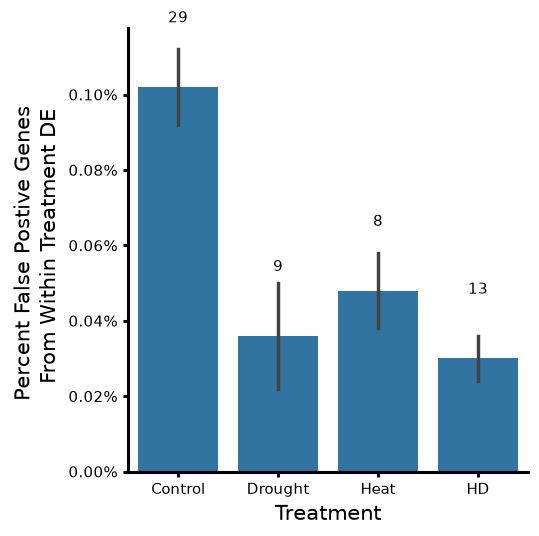

In [38]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.barplot(
    data=lib_mock_summary,
    x="treatment",
    y="% p<0.05",
)
plt.xlabel("Treatment", fontsize=14)
plt.ylabel("Percent False Postive Genes \n From Within Treatment DE", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.grid(False)
ax.bar_label(
    ax.containers[0],
    labels=lib_mock_summary["Number of Sig Genes"]
    .groupby(lib_mock_summary["treatment"])
    .mean()
    .astype(int)
    .values,
    padding=40,
)  # plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

In [28]:
print("mean over splits, by treatment:")
display(
    lib_mock_summary.groupby("treatment", observed=True)[
        [
            "genes_tested",
            "% p<0.05",
            "% p<0.01",
            f"padj<{ALPHA}",
            f"padj<{ALPHA} & |LFC|>={LFC_CUT}",
        ]
    ]
    .mean()
    .round(2)
)
print("\nacross all splits and treatments:")
lib_mock_summary[
    ["% p<0.05", "% p<0.01", f"padj<{ALPHA}", f"padj<{ALPHA} & |LFC|>={LFC_CUT}"]
].describe().round(2)

mean over splits, by treatment:


,genes_tested,% p<0.05,% p<0.01,padj<0.05,padj<0.05 & |LFC|>=1.0
treatment,,,,,
Control,29009.4,0.10,0.0,0.0,0.0
Drought,27363.6,0.04,0.0,0.0,0.0
HD,29461.8,0.03,0.0,0.0,0.0
Heat,27135.0,0.05,0.0,0.0,0.0



across all splits and treatments:


,% p<0.05,% p<0.01,padj<0.05,padj<0.05 & |LFC|>=1.0
count,20.00,20.00,20.0,20.0
mean,0.05,0.00,0.0,0.0
std,0.03,0.00,0.0,0.0
min,0.01,0.00,0.0,0.0
25%,0.03,0.00,0.0,0.0
50%,0.04,0.00,0.0,0.0
75%,0.07,0.00,0.0,0.0
max,0.12,0.01,0.0,0.0


## 1b. Library-level pseudobulk with the batch blocked (`~ mock + replicate`)

Section 1 leaves the batch out of the model, and that flatters it. Every mock contrast there is
*within* a library, but `~mock` carries no library term, so the between-library spread lands in
the residual and inflates the error term the `mock` coefficient is judged against. The result is a
test that looks clean for the wrong reason: the batch variance is not being controlled, it is
padding the noise.

Blocking on `replicate` gives that spread its own coefficients, so `mock` is tested against
within-library variation only. Inside a treatment `replicate` and `libraries` are the same
partition — `leaf_control_rep2` is Control/rep2 and nothing else, and the cell below asserts it —
so the pseudosamples are exactly the ones section 1 built. Only the design changes. The contrast
is named explicitly (`["mock", "B", "A"]`), so the extra term does not disturb it.

Expect the blocked fit to be the **more sensitive** of the two: if the unblocked null looks clean
only because the batch variance is padding the residual, that padding is now gone, and whatever
excess of small p-values remains is genuine within-library noise.

> **Degrees of freedom are tight.** Control has 8 pseudosamples and 5 coefficients (intercept +
> mock + 3 replicate levels), leaving 3 residual df; each stress has 6 and 4, leaving 2. PyDESeq2
> warns that below 3 residual df the log-dispersion distribution is asymmetric and poorly
> estimated by the MAD, so the dispersion prior for the three stresses is shaky. That follows from
> having 3-4 replicates per treatment and is not something the code can fix — but it does mean the
> blocked fit trades a more honest error term for a less stable dispersion estimate. Read the two
> designs together rather than treating either as the single right answer.

In [ ]:
import matplotlib.ticker as mtick

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.barplot(
    data=lib_mock_summary,
    x="treatment",
    y="% p<0.05",
)
plt.xlabel("Treatment", fontsize=14)
plt.ylabel("Percent False Postive Genes \n From Within Treatment DE", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.grid(False)

# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

In [29]:
# Inside a treatment, `replicate` and `libraries` are the same partition, so these are the same
# pseudosamples section 1 already built -- only the model changes.
nested = counts_adata.obs.groupby(["treatment", "replicate"], observed=True)[
    "libraries"
].nunique()
assert (nested == 1).all(), "replicate is not 1:1 with library inside a treatment"

lib_blocked_summary, mock_tables = run_mock_analysis(
    counts_adata,
    analysis="1b. library (~mock + replicate)",
    group_keys=["replicate"],
    strata_keys=["treatment", "libraries"],
    seeds=range(SEED, SEED + N_SPLITS),
    design=f"~{MOCK_KEY} + replicate",
    min_frac_samples=0.5,
    min_cells=1,  # half-libraries are hundreds of cells
    store=mock_tables,
)

# residual df: Control 8 samples - (intercept + mock + 3 replicate) = 3; each stress 6 - 4 = 2
blocked_vs_plain = pd.concat(
    [
        lib_mock_summary.assign(design="~mock"),
        lib_blocked_summary.assign(design="~mock + replicate"),
    ]
)
display(
    blocked_vs_plain.groupby(["design", "treatment"], observed=True)[
        [
            "genes_tested",
            "% p<0.05",
            "% p<0.01",
            f"padj<{ALPHA}",
            f"padj<{ALPHA} & |LFC|>={LFC_CUT}",
        ]
    ]
    .mean()
    .round(2)
)
lib_blocked_summary

c:\Users\mikep\miniconda3\envs\Single_cell\Lib\site-packages\pydeseq2\dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()


  1b. library (~mock + replicate) | seed 0 | Control  4v4 samples,  29064 tested,  0.39% p<0.05,      0 padj<0.05 [20s]


c:\Users\mikep\miniconda3\envs\Single_cell\Lib\site-packages\pydeseq2\dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()


  1b. library (~mock + replicate) | seed 0 | Drought  3v3 samples,  27402 tested,  0.22% p<0.05,      0 padj<0.05 [18s]


c:\Users\mikep\miniconda3\envs\Single_cell\Lib\site-packages\pydeseq2\dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()


...

  1b. library (~mock + replicate) | seed 4 | Heat     3v3 samples,  27150 tested,  0.21% p<0.05,      0 padj<0.05 [8s]


c:\Users\mikep\miniconda3\envs\Single_cell\Lib\site-packages\pydeseq2\dds.py:548: UserWarning: As the residual degrees of freedom is less than 3, the distribution of log dispersions is especially asymmetric and likely to be poorly estimated by the MAD.
  self.fit_dispersion_prior()


  1b. library (~mock + replicate) | seed 4 | HD       3v3 samples,  29474 tested,  0.22% p<0.05,      0 padj<0.05 [9s]


genes_tested  % p<0.05  % p<0.01  padj<0.05  \
design            treatment                                                
~mock             Control         29009.4      0.10      0.00        0.0   
                  Drought         27363.6      0.04      0.00        0.0   
                  HD              29461.8      0.03      0.00        0.0   
                  Heat            27135.0      0.05      0.00        0.0   
~mock + replicate Control         29053.6      0.41      0.03        0.0   
                  Drought         27405.2      0.17      0.01        0.0   
                  HD              29474.6      0.22      0.01        0.0   
                  Heat            27151.8      0.23      0.02        0.0   

                             padj<0.05 & |LFC|>=1.0  
design            treatment                          
~mock             Control                       0.0  
                  Drought                       0.0  
                  HD                            0.0  
                  Heat                          0.0  
~mock + replicate Control                       0.0  
                  Drought                       0.0  
                  HD                            0.0  
                  Heat                          0.0

,analysis,seed,treatment,n_A,n_B,cells_per_sample,genes_kept,genes_tested,% p<0.05,% p<0.01,padj<0.05,padj<0.05 & |LFC|>=1.0
0,1b. library (~mock + replicate),0,Control,4,4,1284.0,29064,29064,0.39,0.02,0,0
1,1b. library (~mock + replicate),0,Drought,3,3,717.0,27402,27402,0.22,0.01,0,0
2,1b. library (~mock + replicate),0,Heat,3,3,1096.5,27153,27153,0.26,0.02,0,0
3,1b. library (~mock + replicate),0,HD,3,3,1845.5,29475,29475,0.21,0.02,0,0
4,1b. library (~mock + replicate),1,Control,4,4,1284.0,29054,29054,0.44,0.03,0,0
5,1b. library (~mock + replicate),1,Drought,3,3,717.0,27406,27406,0.18,0.01,0,0
6,1b. library (~mock + replicate),1,Heat,3,3,1096.5,27150,27150,0.23,0.01,0,0
7,1b. library (~mock + replicate),1,HD,3,3,1845.5,29474,29474,0.21,0.01,0,0
8,1b. library (~mock + replicate),2,Control,4,4,1284.0,29061,29061,0.37,0.04,0,0
9,1b. library (~mock + replicate),2,Drought,3,3,717.0,27407,27407,0.18,0.01,0,0


In [39]:
lib_blocked_summary["Number of Sig Genes"] = (
    lib_blocked_summary["% p<0.05"] * lib_blocked_summary["genes_tested"] / 100
)
lib_blocked_summary
lib_blocked_summary["Number of Sig Genes"].groupby(
    lib_blocked_summary["treatment"]
).mean().astype(int)

treatment
Control    117
Drought     47
HD          64
Heat        62
Name: Number of Sig Genes, dtype: int64

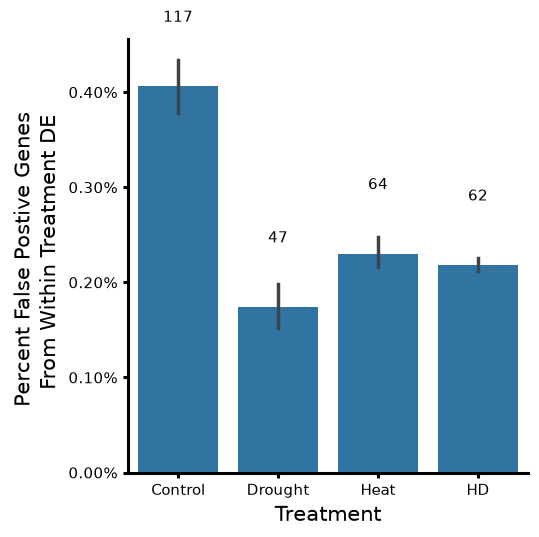

In [40]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.barplot(
    data=lib_blocked_summary,
    x="treatment",
    y="% p<0.05",
)
plt.xlabel("Treatment", fontsize=14)
plt.ylabel("Percent False Postive Genes \n From Within Treatment DE", fontsize=14)
sns.despine()
# ax.grid(False)
# plt.axhline(1, color = 'red', linestyle = 'dashed')
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.grid(False)

ax.bar_label(
    ax.containers[0],
    labels=lib_blocked_summary["Number of Sig Genes"]
    .groupby(lib_blocked_summary["treatment"])
    .mean()
    .astype(int)
    .values,
    padding=40,
)

# plt.xlim((0,3))
# plt.ylim((0, 3))
# handles, labels  =  ax.get_legend_handles_labels()
# ax.legend(loc="upper right")
# plt.title("Current Threshold is 31", fontsize = 20)
plt.xticks(
    fontsize=10,
)  # rotation=90
plt.yticks(fontsize=10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
# plt.ylim(-.02,1)
plt.tight_layout()
# ax.plot([0,1],[0,1], transform=ax.transAxes, linestyle = 'dashed', color = 'k', linewidth = 1.5)
# for line in range(0,full_meta_data.shape[0]):
#      ax.text(pca[:,0][line]+0.01, pca[:,1][line],
#      full_meta_data['plate.pos'][line], horizontalalignment='left',
#      size='medium', color='black', weight='semibold')

## 2. Leiden micro-cluster pseudobulk, mock conditions (`~ mock`)

The micro-clusters are rebuilt exactly as in `redo_de_genes.ipynb`: leiden is re-run one library
at a time on the stored PCA, so no cluster straddles a batch. Each micro-cluster is then split in
half, so a treatment with *k* micro-clusters contributes *k* `A` and *k* `B` pseudosamples of
roughly half the original size. Pseudosamples left with fewer than `MIN_CELLS_PER_SAMPLE` cells
are dropped.

One deviation from `redo_de_genes.ipynb`: size factors use `poscounts` rather than PyDESeq2's
default `ratio`. Half-clusters are sparse enough that no gene is non-zero in *every* pseudosample,
which is the condition `ratio` needs; it then falls back to an iterative fit that is very slow and
frequently reports non-convergence. `poscounts` takes the geometric mean over non-zero counts only
and is the DESeq2-recommended estimator for zero-inflated data. Set `MICRO_SIZE_FACTORS = "ratio"`
to match the real analysis exactly, at the cost of a much longer runtime.

**Runtime.** Each fit is several hundred pseudosamples x ~20-24k genes; with `poscounts` that runs
in tens of seconds to a couple of minutes, and there are `N_SPLITS_MICRO * 4` of them here and
again in 2b. PyDESeq2 usually reports that the parametric dispersion trend did not converge and
falls back to a mean-based trend — expected for pseudosamples this small, and the same fallback
applies to both mock groups.

In [ ]:
micro_labels = pd.Series(index=adata.obs_names, dtype=object)

for library in adata.obs["libraries"].unique():
    sub = adata[adata.obs["libraries"] == library].copy()
    sub.uns.pop("neighbors", None)  # the stored graph belongs to the full object
    sc.pp.neighbors(sub, use_rep="X_pca")
    sc.tl.leiden(
        sub,
        resolution=LEIDEN_RES,
        key_added="_leiden",
        flavor="igraph",
        n_iterations=2,
    )
    micro_labels[sub.obs_names] = library + "_" + sub.obs["_leiden"].astype(str)

    sizes = sub.obs["_leiden"].value_counts()
    print(
        f"{library:>20}: {sub.n_obs:>5} cells -> {sizes.size:>3} clusters, "
        f"median {sizes.median():.0f}, range {sizes.min()}-{sizes.max()}"
    )

counts_adata.obs[LEIDEN_KEY] = pd.Categorical(
    micro_labels.reindex(counts_adata.obs_names)
)
print(
    f"\n{micro_labels.nunique()} micro-clusters, {micro_labels.isna().sum()} cells unassigned"
)
print("\nmicro-clusters per treatment:")
print(counts_adata.obs.groupby("treatment", observed=True)[LEIDEN_KEY].nunique())

In [ ]:
# one fit per (split, treatment) over several hundred pseudosamples -- the slow step (minutes each)
micro_mock_summary, mock_tables = run_mock_analysis(
    counts_adata,
    analysis="2. micro (cell split)",
    group_keys=[LEIDEN_KEY],
    strata_keys=["treatment", LEIDEN_KEY],
    seeds=range(SEED, SEED + N_SPLITS_MICRO),
    size_factors_fit_type=MICRO_SIZE_FACTORS,
    store=mock_tables,
)
micro_mock_summary

## 2b. Same micro-clusters, but whole clusters assigned to a mock condition

*This section is an addition to the request, not part of it — delete it if unwanted.*

Section 2 splits every micro-cluster down the middle, so the `A` and `B` groups are matched
cluster for cluster. That removes the very thing analysis 2 is suspected of mishandling: cells in
one micro-cluster are not independent, but the design counts each cluster as a replicate. Here
each micro-cluster is instead assigned *whole* to `A` or `B` (balanced within treatment), so the
pseudosamples are identical to the ones the real analysis 2 uses and the between-cluster
variability is intact. Comparing 2 and 2b separates counting noise from pseudo-replication.

In [ ]:
if RUN_UNIT_LEVEL_MOCK:
    unit_mock_summary, mock_tables = run_mock_analysis(
        counts_adata,
        analysis="2b. micro (cluster split)",
        group_keys=[LEIDEN_KEY],
        strata_keys=["treatment"],
        unit_key=LEIDEN_KEY,  # whole clusters move together
        seeds=range(SEED, SEED + N_SPLITS_MICRO),
        size_factors_fit_type=MICRO_SIZE_FACTORS,
        store=mock_tables,
    )
else:
    unit_mock_summary = pd.DataFrame()
unit_mock_summary

## Results

All splits from all three mock analyses in one table, then the same numbers next to the real
treatment-vs-Control results from `redo_de_genes.ipynb`.

In [ ]:
mock_summary = pd.concat(
    [lib_mock_summary, lib_blocked_summary, micro_mock_summary, unit_mock_summary],
    ignore_index=True,
)

count_cols = [
    "genes_tested",
    "% p<0.05",
    "% p<0.01",
    f"padj<{ALPHA}",
    f"padj<{ALPHA} & |LFC|>={LFC_CUT}",
]
mock_overview = (
    mock_summary.groupby("analysis", observed=True)[count_cols]
    .agg(["mean", "min", "max"])
    .round(2)
)

if SAVE_SUMMARIES:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    mock_summary.to_csv(RESULTS_DIR / "mock_qc_per_split.csv", index=False)
    mock_overview.to_csv(RESULTS_DIR / "mock_qc_overview.csv")
    print(f"saved summaries to {RESULTS_DIR.resolve()}\n")

mock_overview

In [ ]:
# mock hits next to the real treatment-vs-Control hits from redo_de_genes.ipynb
REAL_PREFIX = {
    "1. library": "library_pseudobulk",
    "2. micro (cell split)": "leiden_micro_pseudobulk",
}

real_rows = []
for analysis, prefix in REAL_PREFIX.items():
    for path in sorted(REAL_RESULTS_DIR.glob(f"{prefix}__*.csv")):
        res = pd.read_csv(path, index_col=0)
        comparison = path.stem.split("__", 1)[1].replace("_", " ")
        real_rows.append(
            {"analysis": analysis, "comparison": comparison, **hit_counts(res)}
        )

if real_rows:
    real = pd.DataFrame(real_rows)
    comparison = pd.concat(
        [
            real.assign(kind="real contrast"),
            mock_summary.assign(kind="mock contrast").rename(
                columns={"treatment": "comparison"}
            )[["analysis", "comparison", "kind", *count_cols]],
        ],
        ignore_index=True,
    )
    display(
        comparison.groupby(["analysis", "kind"], observed=True)[count_cols]
        .mean()
        .round(2)
    )
    display(
        comparison.set_index(["analysis", "kind", "comparison"])[
            count_cols
        ].sort_index()
    )
else:
    print(
        f"no real result tables found in {REAL_RESULTS_DIR.resolve()} -- run redo_de_genes.ipynb first"
    )

### P-value calibration

Under a true null the raw p-values are uniform, so each bar sits on the dashed line. A spike at
the left edge is the signature of an anti-conservative test — that excess is exactly the false
positive rate the QC is after.

In [ ]:
def plot_pvalue_histograms(store, analysis, seed=SEED, treatments=TREATMENTS, bins=40):
    """One p-value histogram per treatment for a single mock split, against the uniform null."""
    panels = [t for t in treatments if (analysis, seed, t) in store]
    if not panels:
        print(f"no stored tables for {analysis!r} at seed {seed}")
        return
    fig, axes = plt.subplots(
        1, len(panels), figsize=(2.9 * len(panels), 2.7), sharey=True
    )
    for ax, treatment in zip(np.atleast_1d(axes), panels):
        pvals = store[(analysis, seed, treatment)]["pvalue"].dropna().to_numpy()
        ax.hist(pvals, bins=np.linspace(0, 1, bins + 1), color=SERIES_COLORS[0])
        ax.axhline(len(pvals) / bins, color=MUTED_INK, linestyle="--", linewidth=1.2)
        ax.set_title(f"{treatment}  (n={len(pvals):,})", fontsize=10)
        ax.set_xlabel("raw p-value")
        ax.tick_params(labelsize=8, colors="#52514e")
    np.atleast_1d(axes)[0].set_ylabel("genes")
    fig.suptitle(
        f"{analysis} — mock B vs A, seed {seed}   (dashed = uniform null)",
        fontsize=11,
        y=1.04,
    )
    fig.tight_layout()
    plt.show()


for analysis in mock_summary["analysis"].unique():
    plot_pvalue_histograms(mock_tables, analysis)

In [ ]:
# false positives per analysis, averaged over splits
hit_col = f"padj<{ALPHA}"
pivot = (
    mock_summary.pivot_table(
        index="treatment", columns="analysis", values=hit_col, observed=True
    )
    .reindex(TREATMENTS)
    .dropna(how="all")
)

x = np.arange(len(pivot))
width = 0.8 / max(pivot.shape[1], 1)
fig, ax = plt.subplots(figsize=(1.9 * len(pivot) + 2.4, 3.4))
for i, analysis in enumerate(pivot.columns):
    offset = (i - (pivot.shape[1] - 1) / 2) * width
    bars = ax.bar(
        x + offset,
        pivot[analysis],
        width * 0.92,
        label=analysis,
        color=SERIES_COLORS[i % len(SERIES_COLORS)],
    )
    ax.bar_label(bars, fmt="%.0f", fontsize=8, padding=2, color="#52514e")

ax.set_xticks(x, pivot.index)
ax.set_ylabel(f"genes with {hit_col} (mean over splits)")
ax.set_title("False positives under mock conditions", fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

pivot.round(1)

### How to read this

* **`% p<0.05` near 5 and `padj<0.05` near 0** — the design is calibrated; hits in the real
  analysis are not an artefact of the pseudobulk structure.
* **`% p<0.05` well above 5** — the test is anti-conservative. Multiply the excess by the number
  of genes tested for a rough count of false positives at the raw threshold; the `padj<0.05`
  column is the more directly useful figure, since it is the same threshold the real analysis
  reports hits at.
* **`% p<0.05` well *below* 5** — the test is conservative, and it is worth asking why before
  taking it as good news. Section 1 lands here because the between-library spread sits in its
  residual (see 1b).
* **Section 1 vs 1b** — 1b blocks on `replicate`, so `mock` is judged against within-library noise
  only, instead of within-library *plus* between-library. 1b is the stricter read of the split-half
  floor. If 1 looks clean and 1b does not, section 1's cleanliness was batch variance padding the
  error term rather than a genuinely well-behaved test. Weigh 1b's numbers against its thin
  residual df (3 for Control, 2 per stress).
* **Section 2 vs 2b** — 2 keeps the mock groups matched cluster-for-cluster and so only measures
  counting noise; 2b lets whole clusters differ between groups, which is what the real analysis
  faces. 2b much worse than 2 means the inflation is pseudo-replication rather than shot noise.
* The `padj<0.05 & |LFC|>=1` column shows how much of the false positive load the effect-size
  filter removes — useful for deciding whether to keep `LFC_CUT` in the real analysis.
* **A clean result here does not clear the real analysis.** Per the caveat at the top, no mock
  contrast crosses a library boundary, so batch effects are absent from all of these nulls by
  construction — including 1b, which *models* the batch but still never contrasts across one. Low
  counts here mean "not explained by counting noise or pseudo-replication"; the remaining suspect
  is the treatment/library confound, which this notebook cannot test.

### Outputs

`de_results/mock_qc/` holds `mock_qc_per_split.csv` (one row per analysis x split x treatment)
and `mock_qc_overview.csv` (aggregated). Set `SAVE_FULL_TABLES = True` to also write the full
PyDESeq2 table for every mock fit. In memory, `mock_tables[(analysis, seed, treatment)]` holds
those tables for follow-up work — e.g. checking whether the same genes keep coming up as false
positives across splits.